In [1]:
%load_ext autoreload
%autoreload 2

from trees.causal_tree import CT
from trees.scanners import *
from trees.data import Data

D = Data()
D.generate(seed=2)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.00000
mean,-0.009573,0.003944,-0.007677,-0.002600,-0.000283,-0.009747,-0.004503,-0.006125,0.003169,0.000704,1.379107,0.49410,0.798805,4999.50000
std,1.004439,1.001655,1.009679,0.997478,0.998088,0.999162,1.005236,1.002576,0.993138,1.009175,3.304737,0.49999,1.131315,2886.89568
min,-3.909285,-3.622546,-3.594449,-3.726431,-3.663526,-3.556142,-3.960377,-3.664461,-3.319230,-3.744099,-12.745325,0.00000,-3.617794,0.00000
25%,-0.685102,-0.667576,-0.693650,-0.683483,-0.672487,-0.676638,-0.677784,-0.685759,-0.675228,-0.682528,-0.889741,0.00000,0.037028,2499.75000
50%,-0.008840,-0.000130,-0.001912,-0.001324,0.003738,-0.007470,-0.015926,-0.001369,-0.008997,-0.005574,1.320127,0.00000,0.773629,4999.50000
75%,0.652743,0.675472,0.681774,0.677402,0.680157,0.649736,0.662925,0.662967,0.667450,0.685626,3.599504,1.00000,1.537666,7499.25000
max,4.022871,3.785640,3.732447,3.245856,4.372230,3.966118,3.681911,4.133362,4.301299,3.912576,14.083919,1.00000,5.484072,9999.00000


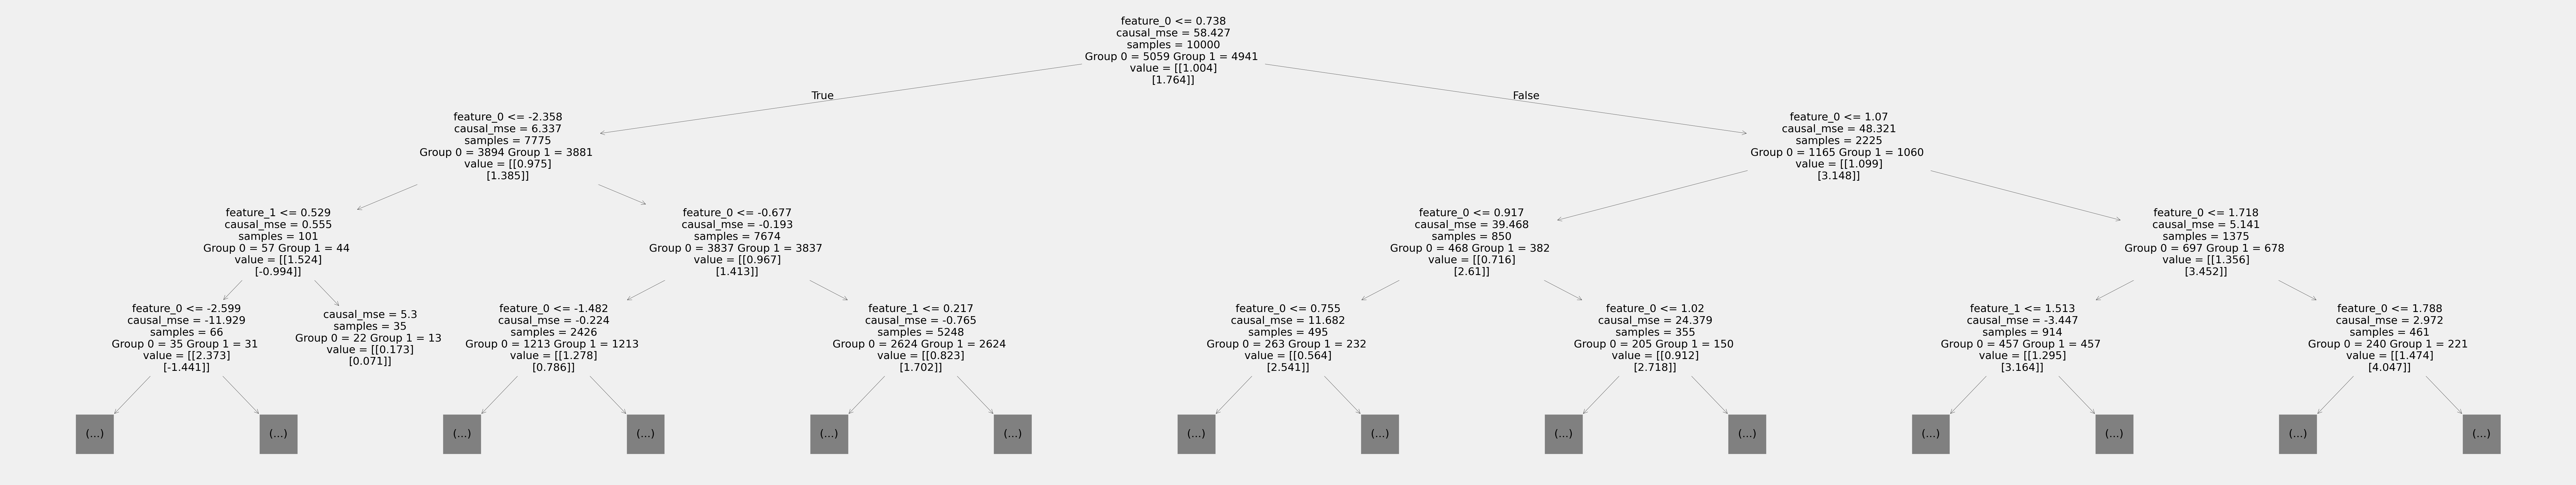

In [2]:
alg = CT()
alg.fit(D=D)
alg.plot_tree(max_depth=3)

In [3]:
alg.subgroups

{1: {'id': 1,
  'condition': 'feature_0 <= 0.738',
  'combined': {'feature_0': (-3.909, 0.738)},
  'features': 1,
  't_est': 0.41,
  'T0': 0.97,
  'T1': 1.39,
  'depth': 1,
  'algorithm': '[Hybrid] CT on D',
  'parents': []},
 2: {'id': 2,
  'condition': 'feature_0 <= 0.738 AND feature_0 <= -2.358',
  'combined': {'feature_0': (-3.909, -2.358)},
  'features': 1,
  't_est': 2.518,
  'T0': 1.52,
  'T1': -0.99,
  'depth': 2,
  'algorithm': '[Hybrid] CT on D',
  'parents': [1]},
 3: {'id': 3,
  'condition': 'feature_0 <= 0.738 AND feature_0 <= -2.358 AND feature_1 <= 0.529',
  'combined': {'feature_0': (-3.909, -2.358), 'feature_1': (-3.623, 0.529)},
  'features': 2,
  't_est': 3.814,
  'T0': 2.37,
  'T1': -1.44,
  'depth': 3,
  'algorithm': '[Hybrid] CT on D',
  'parents': [1, 2]},
 4: {'id': 4,
  'condition': 'feature_0 <= 0.738 AND feature_0 <= -2.358 AND feature_1 <= 0.529 AND feature_0 <= -2.599',
  'combined': {'feature_0': (-3.909, -2.599), 'feature_1': (-3.623, 0.529)},
  'features

In [4]:
alg.feature_importances()

,importance,feature
0,0.986398,feature_0
1,0.013602,feature_1


In [5]:
D.generate_random_condition()
alg.online()

User condition: feature_2 <= 2.33 AND feature_4 <= 0.62 Selectivity: 0.7255
Total subgroups: 502 Valid subgroups: 340
Pruned due to min rows: 162
Pruned due to not being subsets: 0


In [6]:
scan = Weighted(alg)
top = scan.get_topK()
top

100%|██████████| 340/340 [00:01<00:00, 192.99it/s]


,id,condition,combined,features,t_est,T0,T1,depth,algorithm,parents,t,t_r,scan_method,scan_time,total_options,rows,overlap,t_error,t_r_error,invalid_options
0,382,feature_0 <= 0.738 AND feature_0 > -2.358 AND ...,"{'feature_0': (0.404, 0.556), 'feature_1': (1....",2,5.811,-0.86,4.95,16,[Hybrid] CT on D,"[1, 7, 127, 285, 319, 320, 321, 322, 324, 325,...",2.269,2.270,Weighted,1.766,502,31,0.0,3.542,0.001,162
1,494,feature_0 > 0.738 AND feature_0 > 1.07 AND fea...,"{'feature_0': (1.847, 1.974), 'feature_1': (0....",2,4.171,0.95,5.12,9,[Hybrid] CT on D,"[392, 432, 480, 482, 488, 489, 491, 492]",3.114,3.120,Weighted,1.766,502,36,0.0,1.057,0.006,162
2,430,feature_0 > 0.738 AND feature_0 <= 1.07 AND fe...,"{'feature_0': (1.02, 1.045)}",1,4.056,0.45,4.51,5,[Hybrid] CT on D,"[392, 393, 417, 429]",1.900,1.875,Weighted,1.766,502,39,0.0,2.156,0.025,162
3,479,feature_0 > 0.738 AND feature_0 > 1.07 AND fea...,"{'feature_0': (1.07, 1.718), 'feature_1': (1.5...",2,3.939,1.73,5.67,4,[Hybrid] CT on D,"[392, 432, 433]",3.434,3.387,Weighted,1.766,502,40,0.0,0.505,0.047,162
4,497,feature_0 > 0.738 AND feature_0 > 1.07 AND fea...,"{'feature_0': (2.033, 4.023), 'feature_1': (-0...",2,3.685,0.83,4.51,7,[Hybrid] CT on D,"[392, 432, 480, 482, 488, 496]",2.951,2.979,Weighted,1.766,502,32,0.0,0.734,0.028,162


In [7]:
x = scan.op_matrix
x

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.01299202, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.01299202, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

# CT on P

In [9]:
%load_ext autoreload
%autoreload 2

from trees.causal_tree import CTP
from trees.scanners import *
from trees.data import Data

D = Data()
D.generate(seed=1)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.016333,0.016357,0.002555,0.008779,0.014647,-0.000694,-0.001358,-0.012730,0.013282,-0.004639,1.402356,0.486100,0.829563,4999.50000
std,1.004344,0.995399,1.002061,0.990194,1.006272,0.997335,1.003758,0.992082,0.988658,1.003042,3.308234,0.499832,1.127446,2886.89568
min,-3.656440,-3.561627,-4.041680,-4.088489,-3.927514,-3.694204,-4.326887,-3.936503,-3.943142,-3.717130,-11.115662,0.000000,-3.402950,0.00000
25%,-0.670257,-0.658037,-0.664461,-0.664934,-0.677336,-0.665069,-0.678350,-0.691577,-0.646222,-0.672351,-0.820162,0.000000,0.054987,2499.75000
50%,0.023696,0.001688,0.010100,0.018078,0.026985,-0.010995,-0.009655,-0.004745,0.019104,-0.009619,1.357399,0.000000,0.819474,4999.50000
75%,0.694073,0.684831,0.683745,0.678851,0.683389,0.652315,0.670513,0.650550,0.687027,0.653546,3.605168,1.000000,1.594184,7499.25000
max,3.702193,3.786966,3.664094,3.997723,4.055538,4.026849,4.168118,3.559969,3.590576,3.500256,15.034705,1.000000,5.699570,9999.00000


In [10]:
alg = CTP()
alg.fit(D=D)
D.generate_random_condition()

User condition: feature_8 <= 2.197 AND feature_6 <= 0.268 Selectivity: 0.598


('feature_8 <= 2.197 AND feature_6 <= 0.268', 0.598)

Subgroups: 298


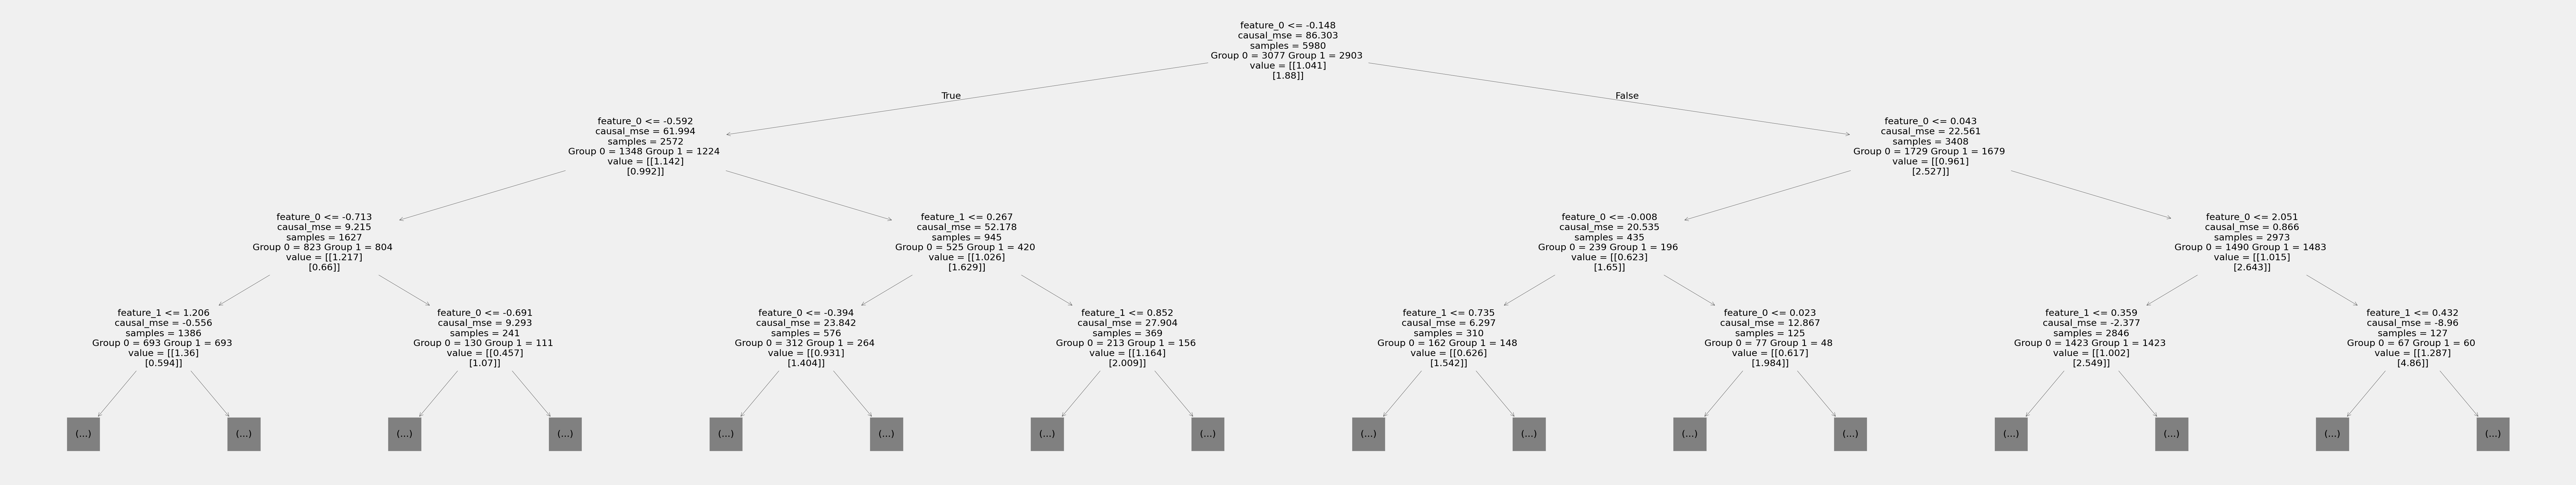

In [13]:
alg.online()
alg.plot_tree(max_depth=3)

In [14]:
scan = Weighted(alg)
top = scan.get_topK()
top


100%|██████████| 298/298 [00:01<00:00, 263.10it/s]


,id,condition,combined,features,t_est,T0,T1,depth,algorithm,parents,...,t_r,scan_method,scan_time,total_options,rows,overlap,score,t_error,t_r_error,invalid_options
0,289,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (0.043, 0.526), 'feature_1': (1....",2,5.792,-1.03,4.77,7,[Online] CT on P,"[130, 148, 149, 247, 287, 288]",...,2.135,Weighted,1.136,298,30,0.0,1.000000,3.662,0.005,0
1,298,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (2.051, 3.702), 'feature_1': (0....",2,5.093,0.95,6.04,4,[Online] CT on P,"[130, 148, 294]",...,3.812,Weighted,1.136,298,39,0.0,0.939658,1.192,0.089,0
2,21,feature_0 <= -0.148 AND feature_0 <= -0.592 AN...,"{'feature_0': (-2.071, -1.677), 'feature_1': (...",2,4.639,3.95,-0.69,14,[Online] CT on P,"[1, 2, 3, 4, 6, 7, 8, 9, 13, 15, 16, 17, 19]",...,1.006,Weighted,1.136,298,31,0.0,0.900466,3.617,0.016,0
3,244,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (1.537, 1.641), 'feature_1': (-0...",2,4.462,-0.61,3.85,9,[Online] CT on P,"[130, 148, 149, 150, 224, 225, 239, 243]",...,2.269,Weighted,1.136,298,34,0.0,0.885186,2.197,0.004,0
4,242,feature_0 > -0.148 AND feature_0 > 0.043 AND f...,"{'feature_0': (1.537, 1.819), 'feature_1': (-1...",2,4.416,-0.47,3.95,9,[Online] CT on P,"[130, 148, 149, 150, 224, 225, 239, 240]",...,2.022,Weighted,1.136,298,34,0.0,0.881215,2.392,0.002,0
